### Importing libraries

In [143]:
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
sns.set_style("whitegrid")


### importing raw data and understanding....

In [105]:
df = pd.read_csv(
    "C:\\Users\\sk\\Documents\\backend\\machineai\\Projects\\customer_segmentation_django\\data\\raw\\OnlineRetail.csv",
    encoding="ISO-8859-1"
)

In [106]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [107]:
print(df.shape)

(541909, 8)


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [109]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Data Cleaning...

In [110]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [111]:
df.dropna(inplace=True)

In [112]:
print(df.shape)
df.isnull().sum()

(406829, 8)


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [113]:
df.duplicated().sum()

np.int64(5225)

In [114]:
df.drop_duplicates(inplace=True)

In [115]:
df.duplicated().sum()

np.int64(0)

### BUSINESS DATA FILTERING

In [116]:
df = df[
    ~df["InvoiceNo"]
    .astype(str)
    .str.contains("C")
]

In [117]:
print(df.shape)

(392732, 8)


### FEATURE ENGINEERING

In [118]:
df["TotalPrice"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

In [119]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France,14.85


In [120]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [121]:
df.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  str           
 1   StockCode    392732 non-null  str           
 2   Description  392732 non-null  str           
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  str           
 8   TotalPrice   392732 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.0 MB


In [122]:
today = dt.datetime(
    2011,
    12,
    11
)

In [123]:
rfm = df.groupby(
    "CustomerID"
).agg({

    "InvoiceDate": lambda x:
        (today - x.max()).days,

    "InvoiceNo": "nunique",

    "TotalPrice": "sum"

})

In [124]:
print(rfm.shape)
rfm.head()

(4339, 3)


,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


In [125]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


plotting datas

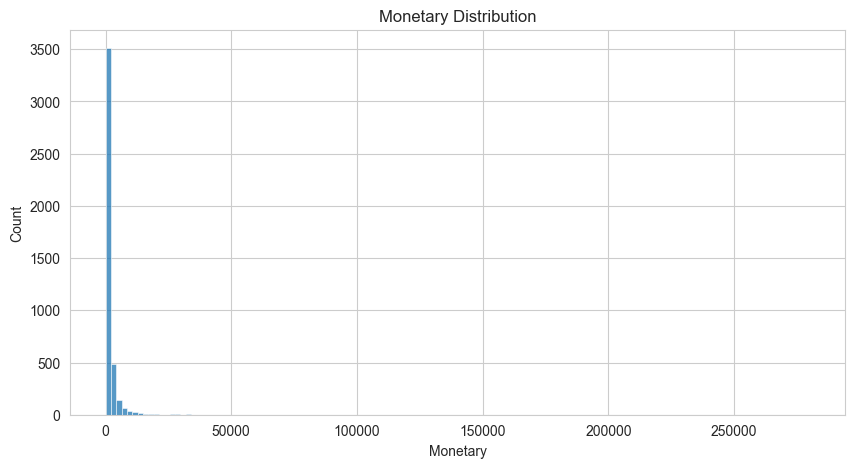

In [126]:
plt.figure(figsize=(10,5))

sns.histplot(rfm["Monetary"])

plt.title("Monetary Distribution")
plt.show()

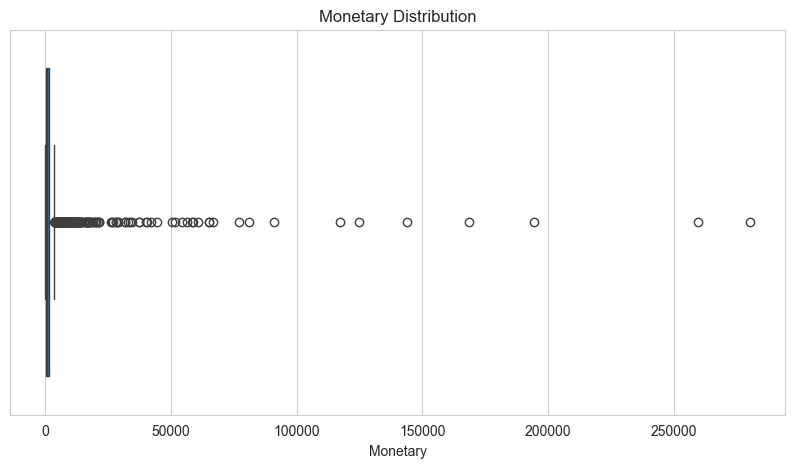

In [127]:
plt.figure(figsize=(10,5))
sns.boxplot(x=rfm["Monetary"])
plt.title("Monetary Distribution")
plt.show()

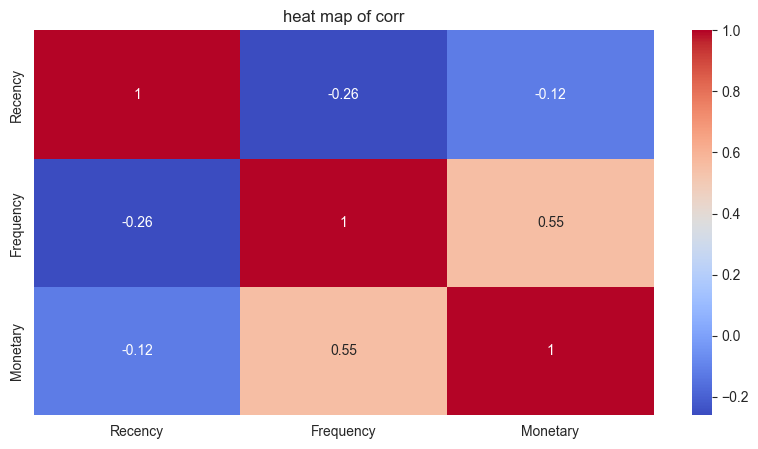

In [128]:
plt.figure(figsize=(10,5))
sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("heat map of corr")
plt.show()

### OUTLIER TREATMENT 

In [130]:
Q1 = rfm["Monetary"].quantile(0.25)
Q3 = rfm["Monetary"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [131]:
rfm = rfm[
    (rfm["Monetary"] >= lower_limit) &
    (rfm["Monetary"] <= upper_limit)
]

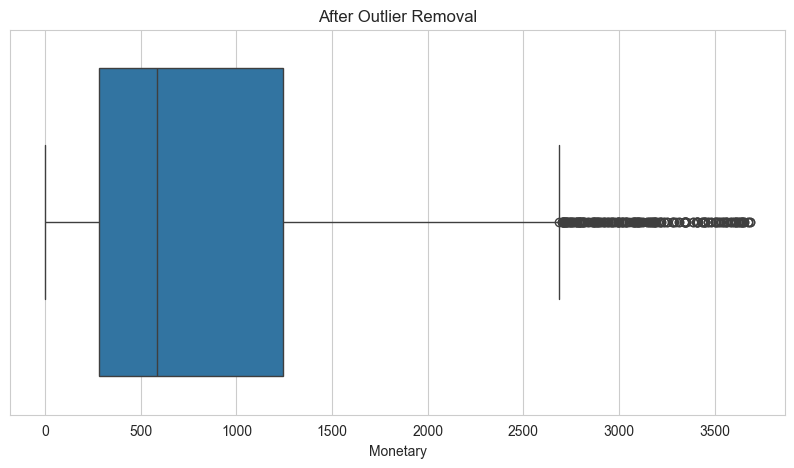

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=rfm["Monetary"])
plt.title("After Outlier Removal")
plt.show()

Feature scaling

In [134]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(rfm)

elbow method to find no of optimal cluster

In [136]:
inertia = []
for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_data)

    inertia.append(kmeans.inertia_)

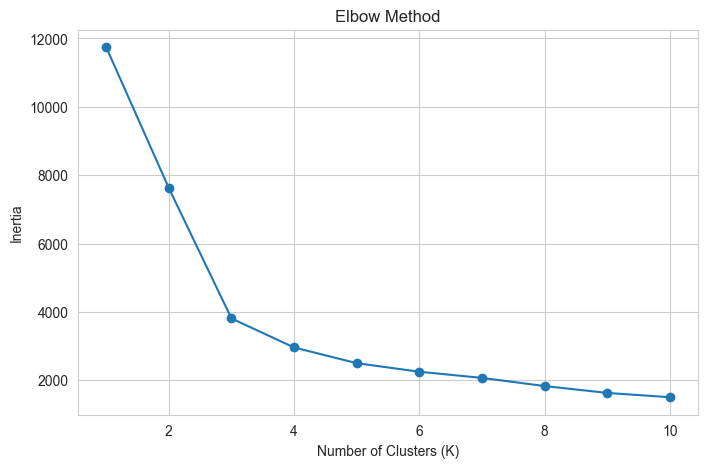

In [137]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    inertia,
    marker='o'
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

##### optimal cluster = 4
### MODEL TRAINING

In [138]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(
    scaled_data
)

In [139]:
rfm["Cluster"] = clusters

In [142]:
rfm['Cluster'].value_counts()

Cluster
3    1671
1     953
0     901
2     389
Name: count, dtype: int64

### PCA (Principal Component Analysis) to visualize clusters

In [144]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_data
)

In [145]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PCA1", "PCA2"]
)

In [146]:
pca_df["Cluster"] = rfm["Cluster"].values

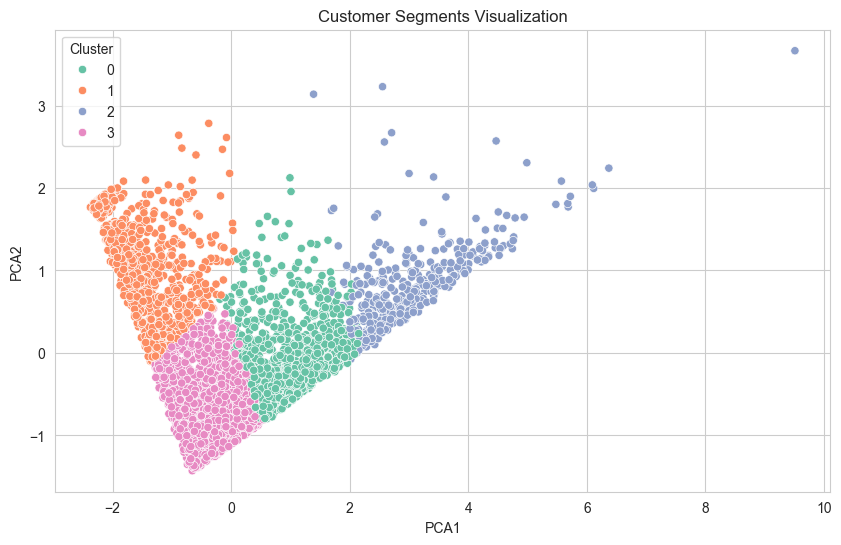

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=pca_df,
    palette="Set2"
)
plt.title("Customer Segments Visualization")
plt.show()

### PCA (Principal Component Analysis) with centroid

In [148]:
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)


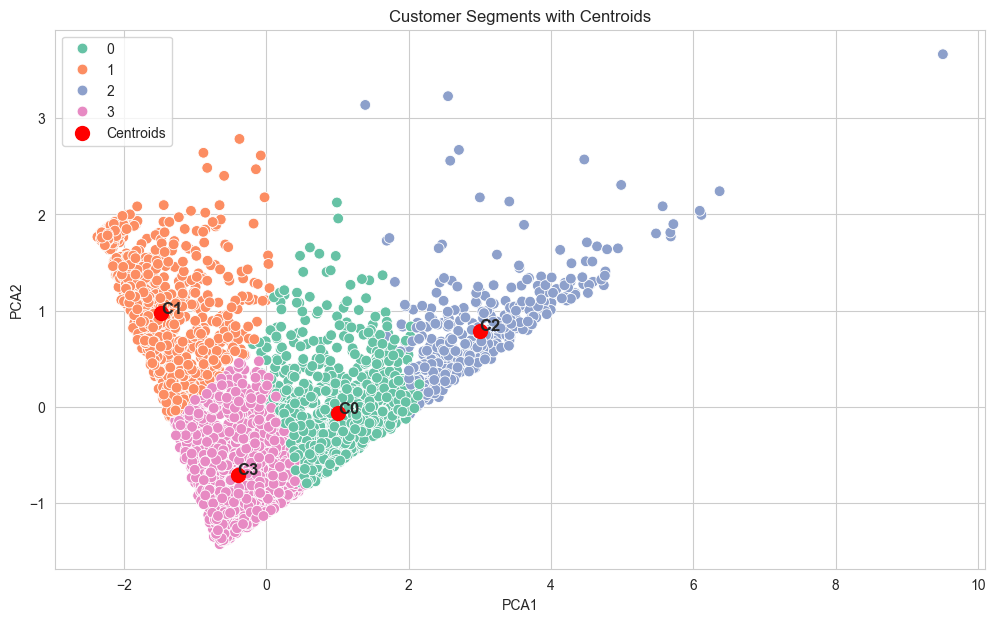

In [154]:
plt.figure(figsize=(12,7))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=pca_df,
    palette="Set2",
    s=60
)
plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c='red',
    s=100,
    marker='o',
    label='Centroids'
)
plt.title("Customer Segments with Centroids")
for i, point in enumerate(centroids_pca):
    plt.text(
        point[0],
        point[1],
        f"C{i}",
        fontsize=12,
        weight='bold'
    )
plt.legend()
plt.show()

#### MODEL EVALUATION

In [155]:
score = silhouette_score(
    scaled_data,
    clusters
)

In [156]:
score

0.4252780631228853

In [157]:
joblib.dump(
    kmeans,
    "../ml/model.pkl"
)

['../ml/model.pkl']

In [158]:
joblib.dump(
    scaler,
    "../ml/scaler.pkl"
)

['../ml/scaler.pkl']

In [159]:
joblib.dump(
    pca,
    "../ml/pca.pkl"
)

['../ml/pca.pkl']